# Part 3: Exploratory Data Analysis & Feature Engineering
## The Supply Chain Resilience Initiative - LogistiCorp
### ADSP 31017 | February 2026

**Objective:** Move raw shipment data to a clean, engineered feature set ready for modeling. We perform EDA to understand distributions, handle missingness, transform variables, engineer new features, and prepare train/test splits.

**Target Variable:** `delivery_time_deviation` (continuous, hours) - predicting how far a shipment deviates from its scheduled delivery time.

**Dataset:** `supply_chain_data_part3_4.csv` (pre-cleaned version with binarized columns)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import pointbiserialr, norm
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error, explained_variance_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression, ElasticNet, lasso_path
from sklearn.svm import SVR
import xgboost as xgb
import geopandas as gpd

import warnings
warnings.filterwarnings('ignore')

SEED = 42

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

---
## 1. Data Description

> **Unit of Analysis:** Each row represents a single shipment record (hourly sensor pings tied to individual shipments) containing GPS telemetry, operational metrics, weather/traffic conditions, supplier scores, and delivery outcomes.

In [ ]:
df = pd.read_csv('supply_chain_data_part3_4.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Span: {(df['timestamp'].max() - df['timestamp'].min()).days} days "
      f"(~{(df['timestamp'].max() - df['timestamp'].min()).days / 365:.1f} years)\n")

# Data types overview
print("Column types:")
print(df.dtypes.value_counts().to_string())
df.head()

Shape: 32,065 rows × 26 columns

Date range: 2021-01-01 00:00:00 → 2024-08-29 00:00:00
Span: 1336 days (~3.7 years)

Column types:
float64           21
int64              3
datetime64[ns]     1
object             1


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.3756,-77.0143,13.3963,2.5324,5.9276,226.1270,4.9514,0,0,0.3591,4.2892,456.5055,0.9861,2.5055,100.7729,-1.2209,1,4.5758,0.5020,0.0338,1.0000,0.5062,0.1017,Moderate Risk,8.3755
1,2021-01-01 01:00:00,33.5078,-117.0369,11.1796,0.0000,1.5920,99.5272,1.0304,1,1,0.2307,7.0184,651.8473,0.4632,8.8678,5313.7381,-8.6002,0,1.8768,0.9668,0.2017,0.8029,0.9808,0.0000,Low Risk,0.4095
2,2021-01-01 02:00:00,30.0206,-75.2692,NaN,4.2546,8.7878,186.6939,4.2202,1,0,0.0272,9.6051,159.0295,0.5986,4.9223,1595.0491,-6.3550,0,4.6453,0.9456,0.2640,0.7918,0.9986,0.1129,Low Risk,4.2376
3,2021-01-01 03:00:00,36.6492,-70.1905,9.8662,1.1423,0.0453,414.7754,0.5302,0,1,0.6166,8.8996,109.6504,0.7427,3.2381,2530.4319,2.9318,1,3.2668,4.6740,0.3629,0.6628,0.9933,0.3055,Moderate Risk,9.2941
4,2021-01-01 04:00:00,30.0013,-70.0122,13.5040,3.5585,8.0049,45.0810,3.6209,0,0,0.9524,0.0618,981.7119,0.4311,6.5783,2146.1902,7.1914,0,8.2154,3.4454,0.0170,0.8636,0.9124,0.3022,Moderate Risk,13.2037


In [ ]:
# Summary statistics for all numeric columns
display(df.describe().T.round(2))

,count,mean,min,25%,50%,75%,max,std
timestamp,32065,2022-10-30 22:35:47.762357760,2021-01-01 00:00:00,2021-11-30 21:00:00,2022-10-31 00:00:00,2023-09-30 00:00:00,2024-08-29 00:00:00,NaN
vehicle_gps_latitude,32062.0000,38.0220,-70.5193,31.2802,36.4117,44.4548,91.5000,6.9509
vehicle_gps_longitude,32062.0000,-90.1126,-120.0000,-106.2533,-86.2934,-73.0793,44.7695,17.3852
fuel_consumption_rate,31448.0000,12.4877,1.8736,9.2235,12.4769,15.7759,23.7382,4.0127
eta_variation_hours,32065.0000,2.0944,0.0000,0.7138,1.9966,3.3277,7.1287,1.5488
traffic_congestion_level,32065.0000,4.9912,0.0000,1.4747,4.9806,8.5345,10.0000,3.5321
warehouse_inventory_level,32065.0000,314.3888,0.4597,187.7039,315.0679,441.1340,825.1320,149.7548
loading_unloading_time,32065.0000,2.2913,-1.0000,0.7744,1.9170,3.7340,5.0000,1.5542
handling_equipment_availability,32065.0000,0.2768,0.0000,0.0000,0.0000,1.0000,1.0000,0.4474
order_fulfillment_status,32065.0000,0.3523,0.0000,0.0000,0.0000,1.0000,1.0000,0.4777


### Target Variable: `delivery_time_deviation`

This is the continuous target representing how many hours a shipment deviates from its scheduled delivery. Higher values indicate greater delays. We use this for regression modeling.

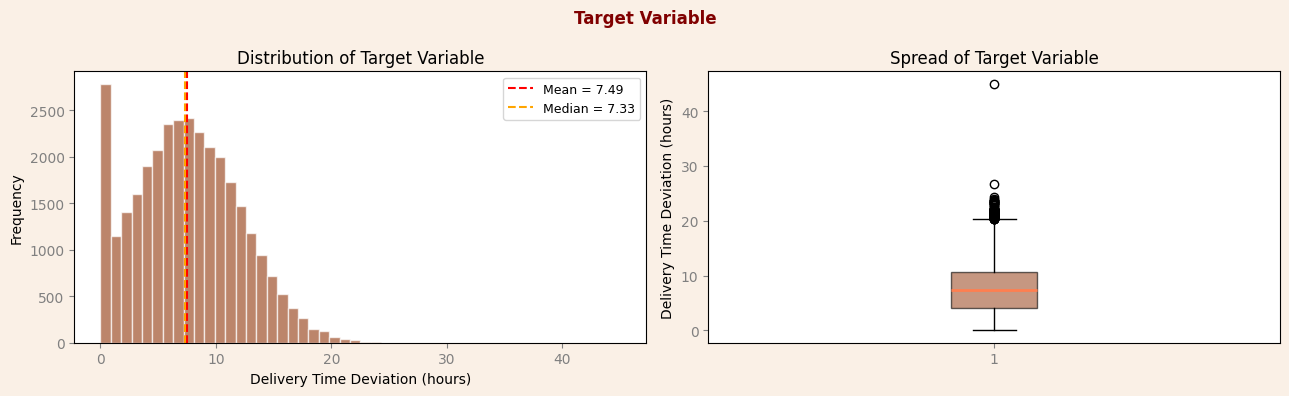

count   32060.0000
mean        7.4950
std         4.5390
min         0.0000
25%         4.1350
50%         7.3350
75%        10.6080
max        45.0000
Name: delivery_time_deviation, dtype: float64


In [ ]:
target = 'delivery_time_deviation'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.set_facecolor('linen')

# Histogram
axes[0].hist(df[target].dropna(), bins=50, color='sienna', edgecolor='white', alpha=0.7)
axes[0].axvline(df[target].mean(), color='red', linestyle='--', lw=1.5, label=f'Mean = {df[target].mean():.2f}')
axes[0].axvline(df[target].median(), color='orange', linestyle='--', lw=1.5, label=f'Median = {df[target].median():.2f}')
axes[0].set_xlabel('Delivery Time Deviation (hours)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Target Variable')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='both', colors='gray')

# Boxplot
axes[1].boxplot(df[target].dropna(), patch_artist=True,
                boxprops=dict(facecolor='sienna', alpha=0.6),
                medianprops=dict(color='coral', linewidth=2))
axes[1].set_ylabel('Delivery Time Deviation (hours)')
axes[1].set_title('Spread of Target Variable')
axes[1].tick_params(axis='both', colors='gray')

fig.suptitle('Target Variable', weight='bold', color='maroon')
plt.tight_layout()
plt.show()

print(df[target].describe().round(3))

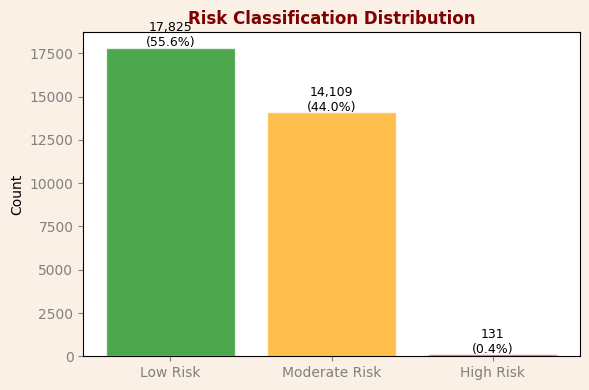

In [ ]:
# Risk classification distribution (for context, not used as feature)
risk_counts = df['risk_classification'].value_counts()
risk_pct = (risk_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
fig.set_facecolor('linen')
colors = {'Low Risk': 'green', 'Moderate Risk': 'orange', 'High Risk': 'red'}
bar_colors = [colors.get(r, 'gray') for r in risk_counts.index]
bars = ax.bar(risk_counts.index, risk_counts.values, color=bar_colors, edgecolor='white', alpha=0.7)
for bar, (cat, val) in zip(bars, risk_counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 80,
            f'{val:,}\n({risk_pct[cat]}%)', ha='center', fontsize=9)
ax.set_title('Risk Classification Distribution', weight='bold', color='maroon')
ax.set_ylabel('Count')
ax.tick_params(axis='both', colors='gray')
plt.tight_layout()
plt.show()

### Column Classification

We classify each column by its availability at shipment departure:

| Category | Columns | Rationale |
|----------|---------|-----------|
| **Pre-shipment features** (usable) | `traffic_congestion_level`, `warehouse_inventory_level`, `loading_unloading_time`, `handling_equipment_availability`, `weather_condition_severity`, `port_congestion_level`, `shipping_costs`, `supplier_reliability_score`, `lead_time_days`, `historical_demand`, `route_risk_level`, `driver_behavior_score`, `fatigue_monitoring_score` | Known or forecastable before the truck leaves the warehouse |
| **Target** | `delivery_time_deviation` | The outcome we want to predict |
| **Post-shipment / outcome** (excluded) | `order_fulfillment_status`, `delay_probability`, `disruption_likelihood_score`, `risk_classification`, `eta_variation_hours`, `customs_clearance_time`, `cargo_condition_status` | Measured during or after transit - using these as predictors would constitute data leakage |
| **In-transit sensors** (excluded) | `fuel_consumption_rate`, `iot_temperature` | Real-time sensor data collected during the shipment, not available before departure |
| **Metadata** (used for engineering only) | `timestamp`, `vehicle_gps_latitude`, `vehicle_gps_longitude` | Timestamp used to extract day-of-week; GPS not retained as raw features |

---
## 2. Exploratory Data Analysis

### 2.1 Missing Values

In [ ]:
# Missing value summary
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(4)

missing_df = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_pct
}).sort_values('Missing %', ascending=False)

print("Columns with missing values:")
display(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal rows: {len(df):,}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum():,} "
      f"({df.isnull().any(axis=1).mean()*100:.2f}%)")

Columns with missing values:


,Missing Count,Missing %
iot_temperature,662,2.0646
driver_behavior_score,618,1.9273
fuel_consumption_rate,617,1.9242
delay_probability,5,0.0156
delivery_time_deviation,5,0.0156
vehicle_gps_latitude,3,0.0094
vehicle_gps_longitude,3,0.0094
shipping_costs,1,0.0031
weather_condition_severity,1,0.0031
supplier_reliability_score,1,0.0031



Total rows: 32,065
Rows with any NaN: 1,864 (5.81%)


### 2.2 Missingness Analysis (MAR Justification)

Only `iot_temperature`, `driver_behavior_score`, and `fuel_consumption_rate` have missing values (~2% each). To determine whether this missingness is related to the target or other features, we compute point-biserial correlations between each missing-indicator and every numeric variable. If the correlation between a missing-indicator and a variable is practically zero (|r| < 0.01) and/or statistically insignificant (p > 0.05), the missingness is unrelated to that variable - evidence for Missing At Random (MAR).

In [ ]:
# Point-biserial correlation: missing indicator vs. every numeric variable
missing_cols = df.columns[df.isnull().sum() > 0].tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

mar_results = []
for mcol in missing_cols:
    indicator = df[mcol].isnull().astype(int)
    for ncol in numeric_cols:
        valid = df[ncol].notna() & indicator.notna()
        if valid.sum() > 10:
            r, p = pointbiserialr(indicator[valid], df.loc[valid, ncol])
            mar_results.append({
                'missing_column': mcol,
                'numeric_column': ncol,
                'correlation': round(r, 5),
                'p_value': round(p, 5),
                'significant': p < 0.05
            })

mar_df = pd.DataFrame(mar_results)

# Summary: how many significant correlations, and their magnitudes
print("Point-biserial correlations between missing indicators and numeric variables:\n")
for mcol in missing_cols:
    sub = mar_df[mar_df['missing_column'] == mcol]
    n_sig = sub['significant'].sum()
    max_abs_r = sub['correlation'].abs().max()
    print(f"  {mcol}:")
    print(f"    Significant (p < 0.05): {n_sig}/{len(sub)}")
    print(f"    Max |correlation|: {max_abs_r:.5f}")
    if n_sig > 0:
        sig_sub = sub[sub['significant']].sort_values('correlation', key=abs, ascending=False)
        display(sig_sub.head(5))
    print()

print("Conclusion: Even when statistically significant, correlations are negligible (|r| < 0.01).")
print("→ Missingness is consistent with MAR. Safe to drop these rows.")

Point-biserial correlations between missing indicators and numeric variables:

  vehicle_gps_latitude:
    Significant (p < 0.05): 0/24
    Max |correlation|: 0.00965

  vehicle_gps_longitude:
    Significant (p < 0.05): 0/24
    Max |correlation|: 0.00965

  fuel_consumption_rate:
    Significant (p < 0.05): 2/24
    Max |correlation|: 0.01121


,missing_column,numeric_column,correlation,p_value,significant
60,fuel_consumption_rate,supplier_reliability_score,0.0112,0.0446,True
61,fuel_consumption_rate,lead_time_days,-0.0112,0.0447,True



  weather_condition_severity:
    Significant (p < 0.05): 0/24
    Max |correlation|: 0.01008

  port_congestion_level:
    Significant (p < 0.05): 0/24
    Max |correlation|: 0.00955

  shipping_costs:
    Significant (p < 0.05): 0/24
    Max |correlation|: 0.00880

  supplier_reliability_score:
    Significant (p < 0.05): 1/24
    Max |correlation|: 0.01120


,missing_column,numeric_column,correlation,p_value,significant
154,supplier_reliability_score,port_congestion_level,-0.0112,0.0450,True



  lead_time_days:
    Significant (p < 0.05): 1/24
    Max |correlation|: 0.01120


...


  fatigue_monitoring_score:
    Significant (p < 0.05): 0/24
    Max |correlation|: 0.00862

  delay_probability:
    Significant (p < 0.05): 1/24
    Max |correlation|: 0.01175


,missing_column,numeric_column,correlation,p_value,significant
322,delay_probability,port_congestion_level,-0.0118,0.0354,True



  delivery_time_deviation:
    Significant (p < 0.05): 1/24
    Max |correlation|: 0.01175


,missing_column,numeric_column,correlation,p_value,significant
346,delivery_time_deviation,port_congestion_level,-0.0118,0.0354,True



Conclusion: Even when statistically significant, correlations are negligible (|r| < 0.01).
→ Missingness is consistent with MAR. Safe to drop these rows.


### 2.3 Feature Distributions

Histograms and boxplots for the 13 pre-shipment features we plan to use, plus the target.

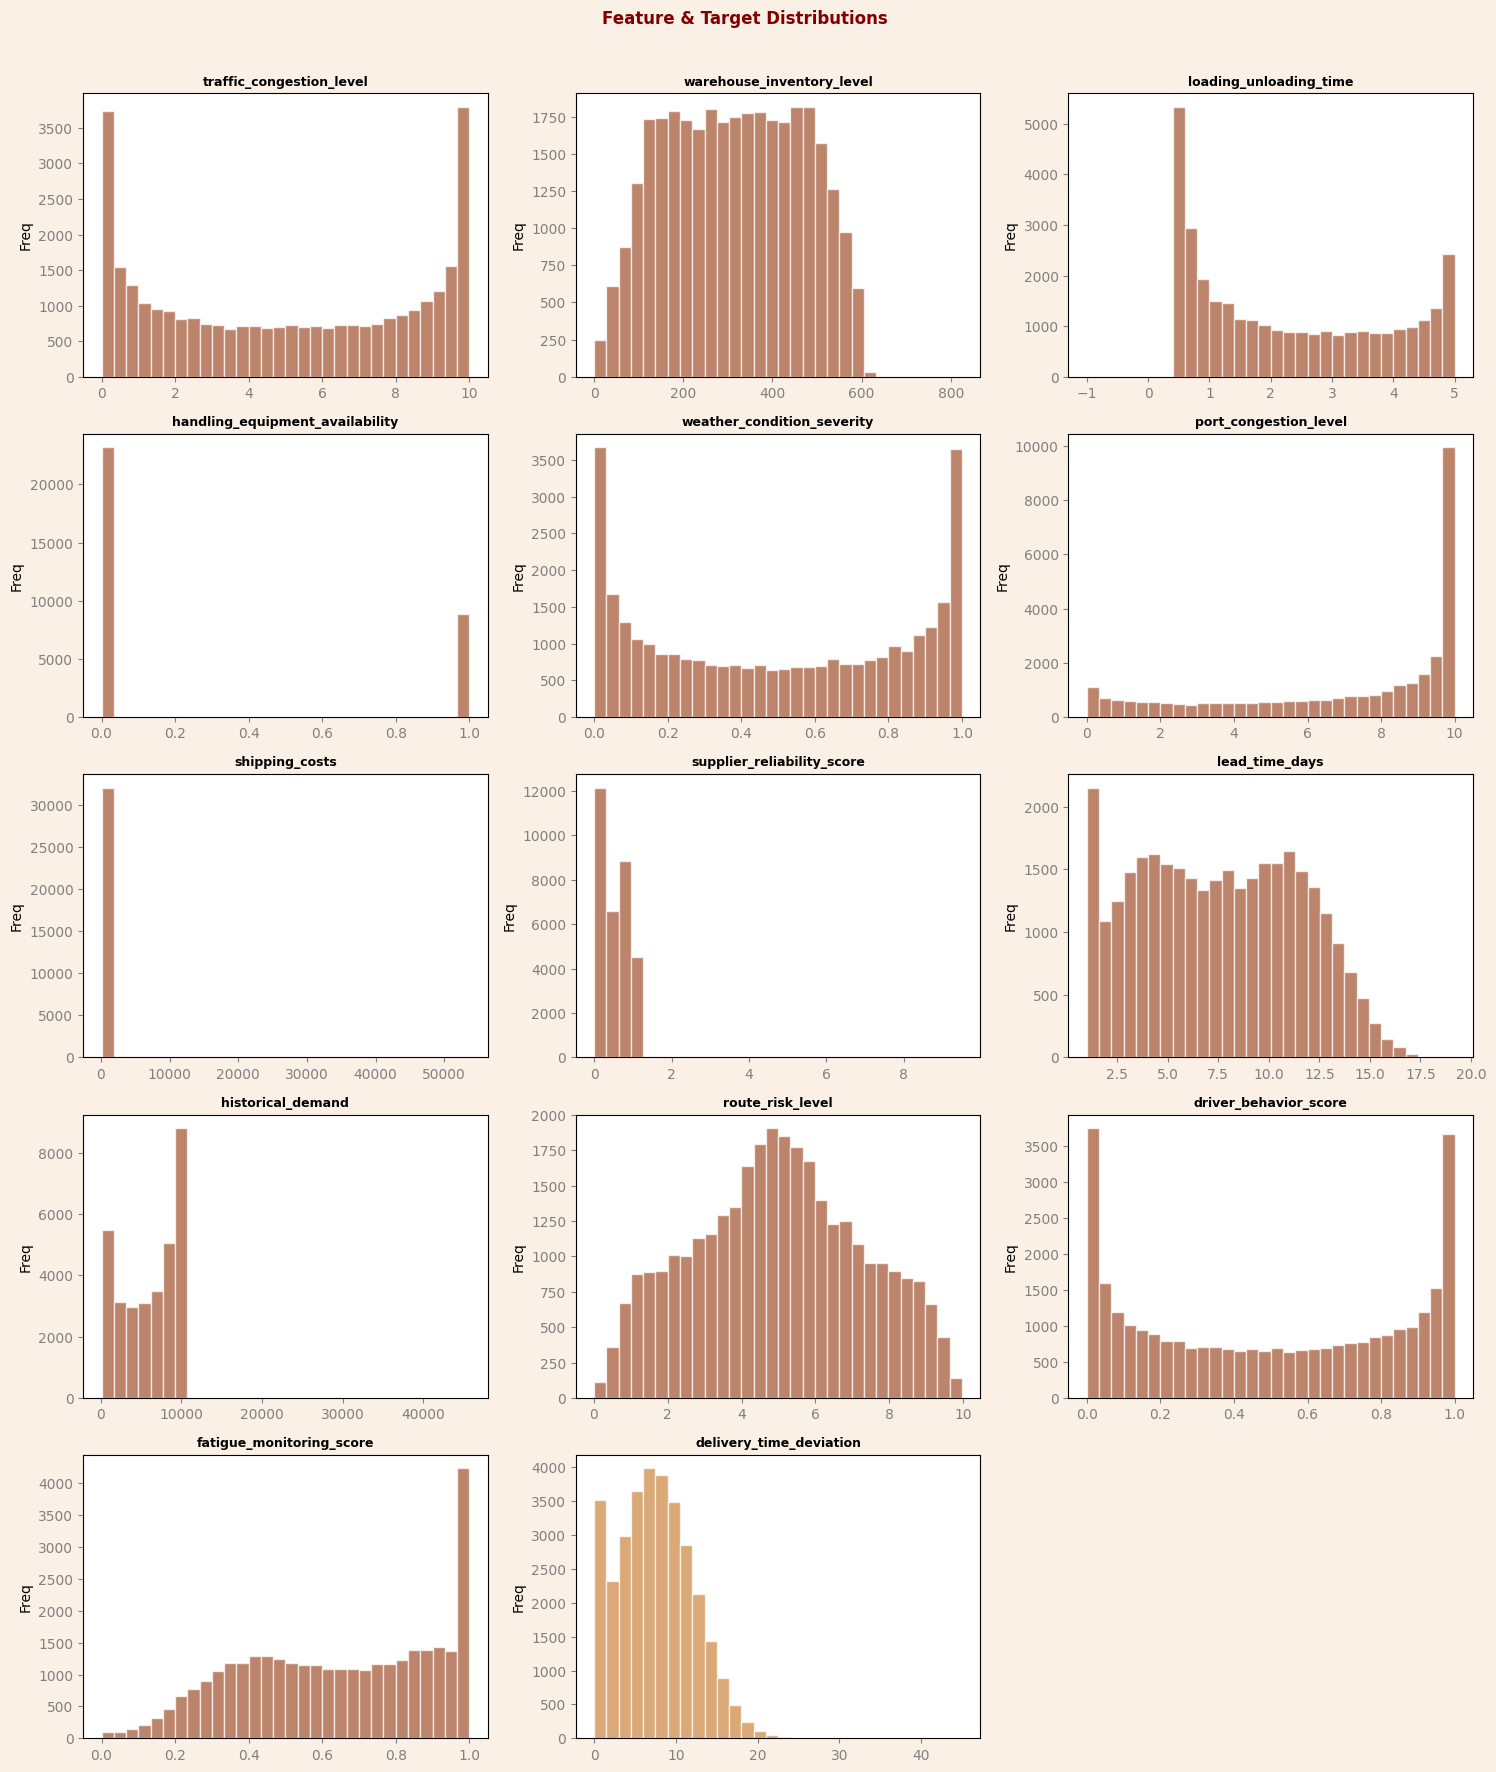

In [ ]:
# Features we plan to use
raw_features = [
    'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time',
    'handling_equipment_availability', 'weather_condition_severity', 'port_congestion_level',
    'shipping_costs', 'supplier_reliability_score', 'lead_time_days',
    'historical_demand', 'route_risk_level', 'driver_behavior_score', 'fatigue_monitoring_score'
]

plot_cols = raw_features + [target]
n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

# Histograms
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
fig.set_facecolor('linen')
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    color = 'peru' if col == target else 'sienna'
    axes[i].hist(df[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.7)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Freq')
    axes[i].tick_params(axis='both', colors='gray')

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Feature & Target Distributions', weight='bold', color='maroon', y=1.01)
plt.tight_layout()
plt.show()

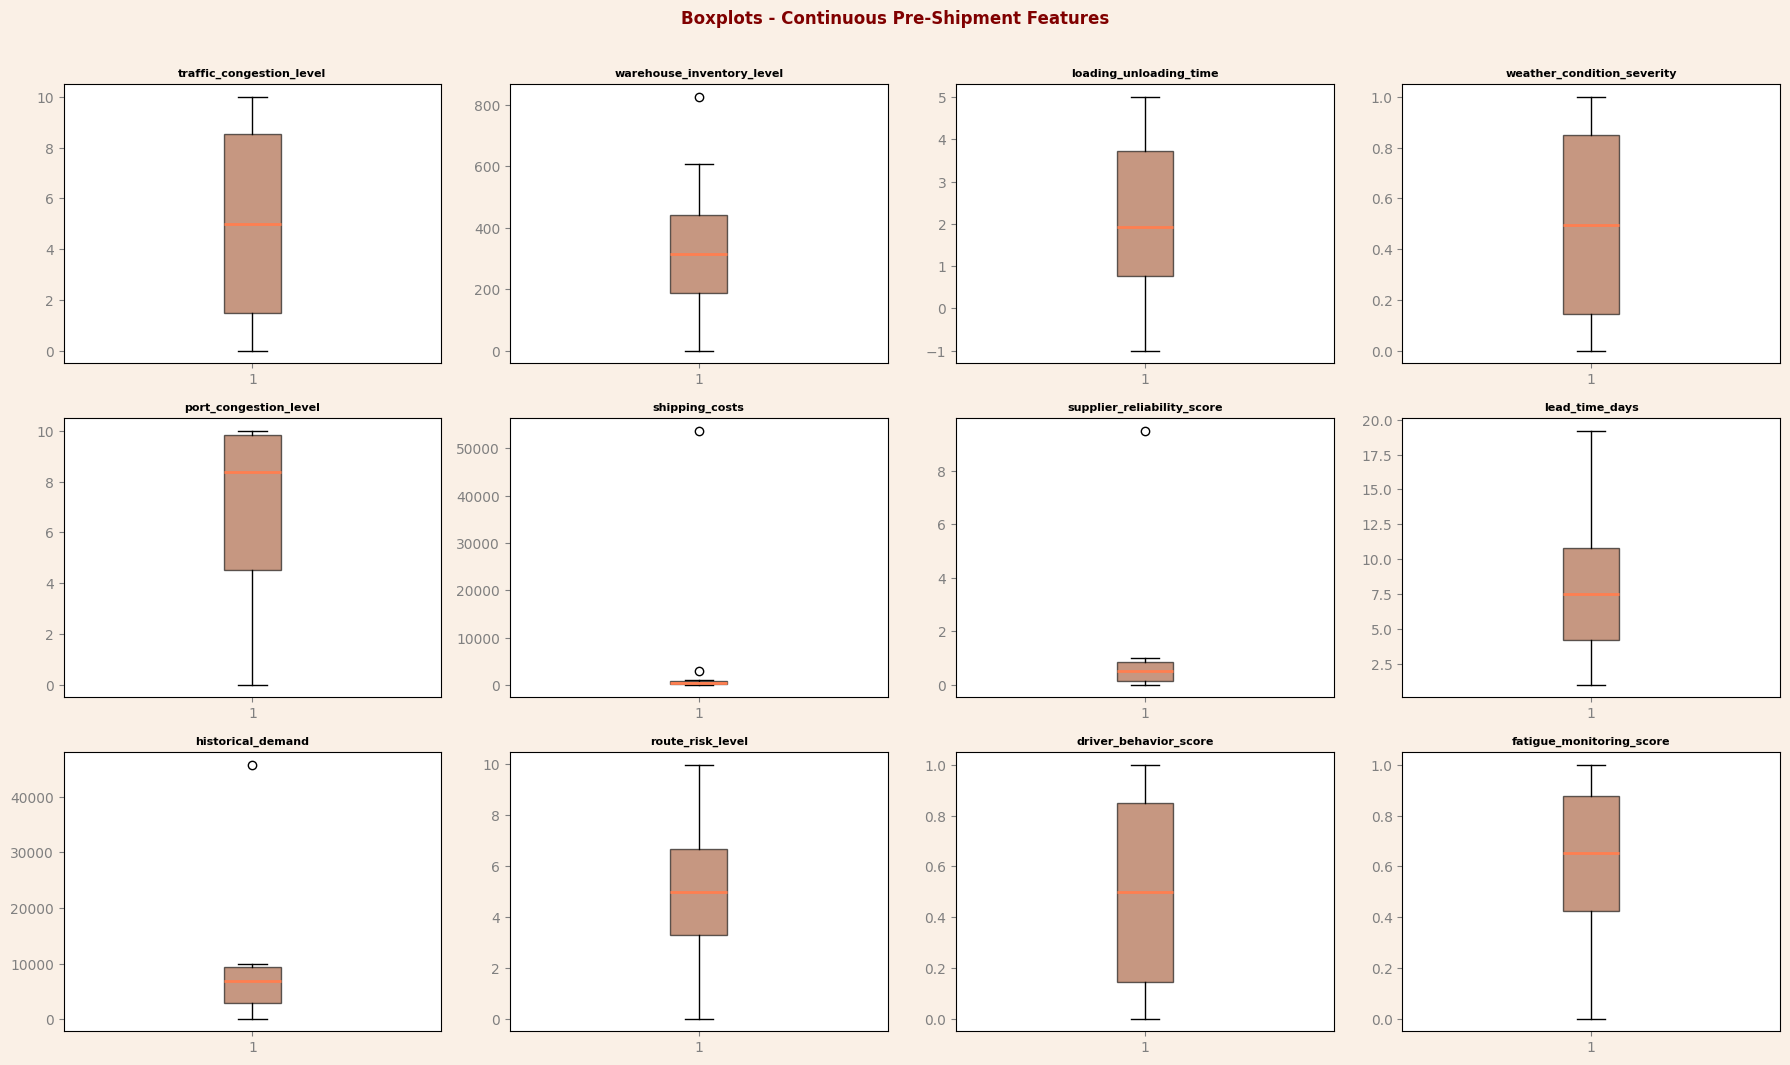

In [ ]:
# Boxplots for continuous features
continuous_features = [c for c in raw_features if df[c].nunique() > 2]

n_rows_bp = math.ceil(len(continuous_features) / 4)
fig, axes = plt.subplots(n_rows_bp, 4, figsize=(18, 3.5 * n_rows_bp))
fig.set_facecolor('linen')
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='sienna', alpha=0.6),
                    medianprops=dict(color='coral', linewidth=2))
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].tick_params(axis='both', colors='gray')

for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Boxplots - Continuous Pre-Shipment Features', weight='bold', color='maroon', y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Correlation Analysis

We examine Pearson correlations among the 13 pre-shipment features and the target. The pairwise linear correlations with the target appear weak, which could suggest that non-linear models may outperform linear ones - though this is a hypothesis we will test in Part 4.

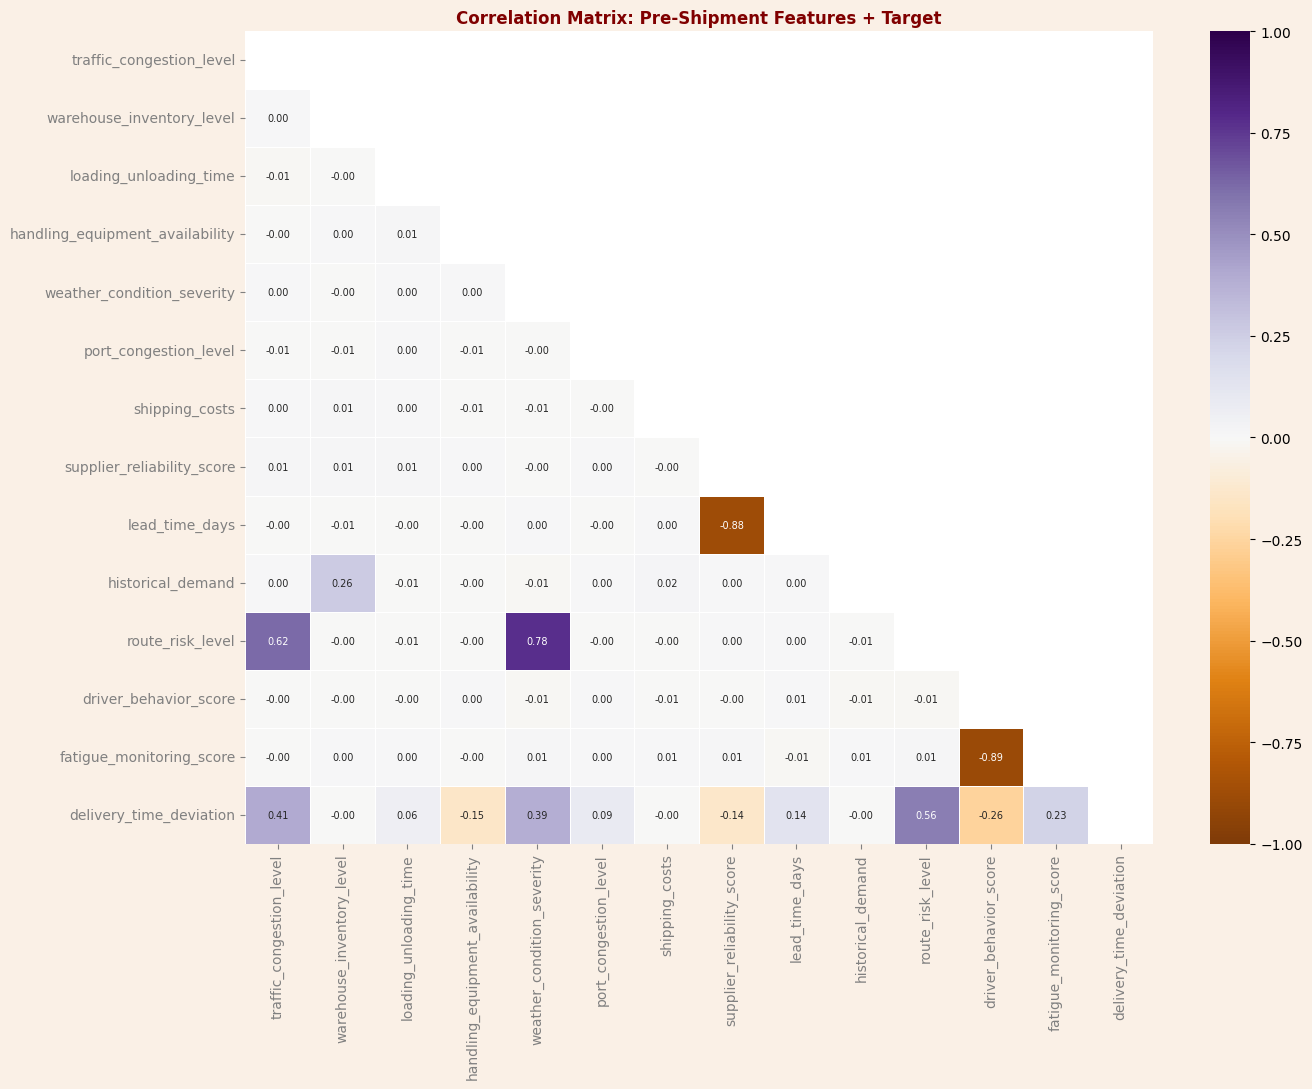

Correlations with delivery_time_deviation:
route_risk_level                   0.5560
traffic_congestion_level           0.4053
weather_condition_severity         0.3898
driver_behavior_score             -0.2630
fatigue_monitoring_score           0.2333
handling_equipment_availability   -0.1457
supplier_reliability_score        -0.1390
lead_time_days                     0.1389
port_congestion_level              0.0922
loading_unloading_time             0.0602
historical_demand                 -0.0044
shipping_costs                    -0.0020
warehouse_inventory_level         -0.0004


In [ ]:
# Correlation heatmap: features + target
corr_cols = raw_features + [target]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.set_facecolor('linen')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='PuOr',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix: Pre-Shipment Features + Target', weight='bold', color='maroon')
ax.tick_params(axis='both', colors='gray')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)
print(f"Correlations with {target}:")
print(target_corr.round(4).to_string())

### 2.5 Temporal Patterns

We examine the daily record volume and day-of-week distribution to justify our decision **not** to use a time-series split.

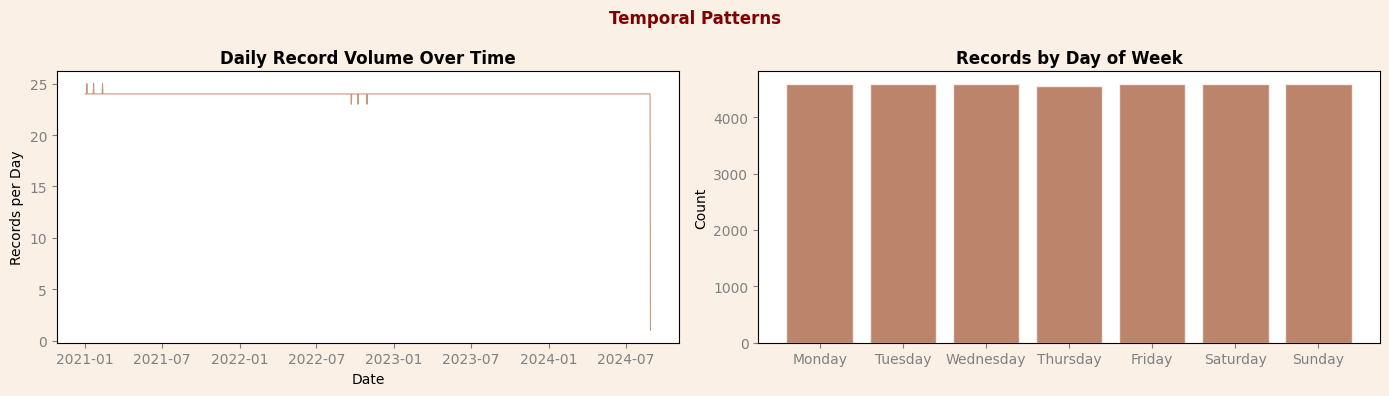

In [ ]:
# Daily record volume over time
df_sorted = df.sort_values('timestamp')
daily_counts = df_sorted.set_index('timestamp').resample('D').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.set_facecolor('linen')

axes[0].plot(daily_counts.index, daily_counts.values, color='sienna', alpha=0.6, linewidth=0.8)
axes[0].set_title('Daily Record Volume Over Time', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Records per Day')
axes[0].tick_params(axis='both', colors='gray')

# Day-of-week distribution
dow_counts = df['timestamp'].dt.day_name().value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.reindex(day_order)
axes[1].bar(dow_counts.index, dow_counts.values, color='sienna', edgecolor='white', alpha=0.7)
axes[1].set_title('Records by Day of Week', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='both', colors='gray')

fig.suptitle('Temporal Patterns', weight='bold', color='maroon')
plt.tight_layout()

plt.show()

---
## 3. Processing Steps & Reasoning

### 3.1 Imputation: Drop Missing Rows (~2%)

Based on the MAR analysis above, the three columns with missing values (`iot_temperature`, `driver_behavior_score`, `fuel_consumption_rate`) have missingness that is uncorrelated with the target and other features. Since only ~2% of rows are affected, we drop them rather than impute.

In [ ]:
# Drop rows with any missing values in the columns that have them
rows_before = len(df)
df = df.dropna(subset=['iot_temperature', 'driver_behavior_score', 'fuel_consumption_rate'])
rows_after = len(df)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Dropped:     {rows_before - rows_after:,} ({(rows_before - rows_after)/rows_before*100:.2f}%)")
print(f"\nRemaining NaN values: {df.isnull().sum().sum()}")

Rows before: 32,065
Rows after:  30,208
Dropped:     1,857 (5.79%)

Remaining NaN values: 17


In [ ]:
# Drop any remaining rows with NaN in other columns (timestamp parse failures, etc.)
rows_before_2 = len(df)

df = df.dropna()
print(f"Final clean shape: {df.shape}")
print(f"Additional rows dropped: {rows_before_2 - len(df):,}")

Final clean shape: (30201, 26)
Additional rows dropped: 7


### 3.2 Feature Selection

We select 13 pre-shipment features - variables that are known or forecastable **before the truck leaves the warehouse**. Each feature is justified by its business relevance:

| Feature | Rationale |
|---------|-----------|
| `traffic_congestion_level` | Real-time traffic data available at dispatch; directly affects transit time |
| `warehouse_inventory_level` | Low inventory may cause loading delays or partial shipments |
| `loading_unloading_time` | Historical/estimated loading duration; affects departure punctuality |
| `handling_equipment_availability` | Binary (0/1); equipment shortages at warehouse delay dispatch |
| `weather_condition_severity` | Weather forecast at dispatch; severe weather causes transit delays |
| `port_congestion_level` | Port status at routing time; congested ports cause cascading delays |
| `shipping_costs` | Quoted cost (known pre-departure); may proxy for route complexity or distance |
| `supplier_reliability_score` | Historical supplier metric; unreliable suppliers cause upstream delays |
| `lead_time_days` | Expected lead time (set pre-departure); longer lead times = more exposure to disruption |
| `historical_demand` | Demand forecast; high demand periods strain logistics capacity |
| `route_risk_level` | Historical risk score for the planned route |
| `driver_behavior_score` | Driver's historical performance score (assigned before dispatch) |
| `fatigue_monitoring_score` | Driver fatigue baseline at dispatch (pre-trip assessment) |

**Excluded columns** and reasons:
- `order_fulfillment_status` - outcome variable (whether order was fulfilled on time)
- `delay_probability`, `disruption_likelihood_score`, `risk_classification` - target-like variables; using them as predictors would be data leakage
- `delivery_time_deviation` - this is our target
- `eta_variation_hours`, `customs_clearance_time`, `cargo_condition_status` - measured during/after transit
- `fuel_consumption_rate`, `iot_temperature` - in-transit sensor readings, not available pre-departure
- `vehicle_gps_latitude`, `vehicle_gps_longitude` - raw GPS coordinates not directly interpretable as features
- `timestamp` - used only for feature engineering (day of week extraction)

---
## 4. Feature Engineering

We create two new features not present in the raw data. Both are derived from pre-shipment information and capture business-relevant risk signals.

### Feature 1: `day_of_week` (extracted from `timestamp`)

**Business logic:** Shipping and warehouse operations vary predictably by weekday. Friday dispatches may face weekend delays at distribution centers. Monday shipments encounter backlogs from the weekend. Weekday vs. weekend staffing patterns affect loading times and handling capacity.

We extract the day of the week from the timestamp and one-hot encode it (dropping one level to avoid multicollinearity).

### Feature 2: `driver_risk_score` (composite of `driver_behavior_score` × `fatigue_monitoring_score`)

**Business logic:** A driver with a poor behavior score who is also fatigued represents the highest risk combination for delivery disruption. Neither feature alone captures this interaction - a well-rested but reckless driver or a careful but fatigued driver are both lower-risk than the combination. The formula `(1 - driver_behavior_score) * fatigue_monitoring_score` produces higher values when behavior is poor (low score -> high `1 - score`) AND fatigue is high (high `fatigue_monitoring_score`). This lets the model capture the *joint* effect.

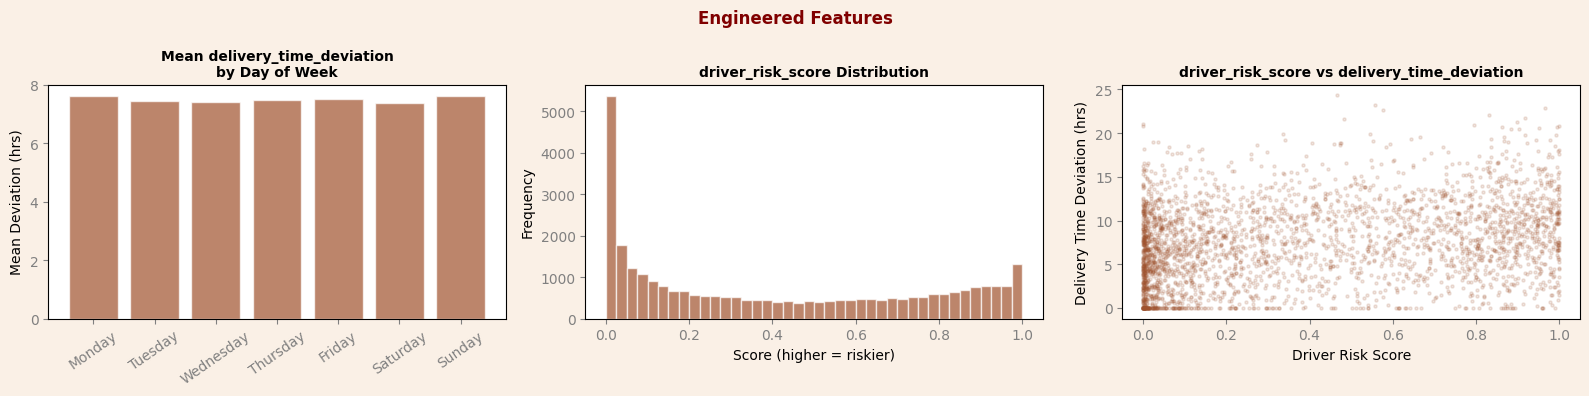

Correlation with delivery_time_deviation:
  driver_risk_score: 0.2575
  is_Monday: nan
  is_Tuesday: 0.0095
  is_Wednesday: -0.0049
  is_Thursday: -0.0062
  is_Friday: -0.0005
  is_Saturday: 0.0002
  is_Sunday: -0.0099


In [ ]:
# --- Feature 1: Day of week ---
df['day_of_week'] = df['timestamp'].dt.day_name()

# --- Feature 2: Driver risk score ---
# Higher = riskier (poor behavior + high fatigue)
df['driver_risk_score'] = (1 - df['driver_behavior_score']) * df['fatigue_monitoring_score']

# Visualize the engineered features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.set_facecolor('linen')

# Day of week vs target
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_target = df.groupby('day_of_week')[target].mean().reindex(day_order)
axes[0].bar(dow_target.index, dow_target.values, color='sienna', edgecolor='white', alpha=0.7)
axes[0].set_title(f'Mean {target}\nby Day of Week', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Mean Deviation (hrs)')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='both', colors='gray')

# Driver risk score distribution
axes[1].hist(df['driver_risk_score'].dropna(), bins=40, color='sienna', edgecolor='white', alpha=0.7)
axes[1].set_title('driver_risk_score Distribution', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Score (higher = riskier)')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='both', colors='gray')

# Driver risk score vs target (scatter sample)
sample = df.sample(min(3000, len(df)), random_state=SEED)
axes[2].scatter(sample['driver_risk_score'], sample[target], alpha=0.15, s=5, color='sienna')
axes[2].set_title(f'driver_risk_score vs {target}', fontweight='bold', fontsize=10)
axes[2].set_xlabel('Driver Risk Score')
axes[2].set_ylabel('Delivery Time Deviation (hrs)')
axes[2].tick_params(axis='both', colors='gray')

fig.suptitle('Engineered Features', weight='bold', color='maroon')
plt.tight_layout()
plt.show()

# Correlation of engineered features with target
print(f"Correlation with {target}:")
print(f"  driver_risk_score: {df['driver_risk_score'].corr(df[target]):.4f}")

for day in day_order:
    print(f"  is_{day}: {r:.4f}")
    r = (df['day_of_week'] == day).astype(int).corr(df[target])

### 4.3 Categorical Encoding

The `day_of_week` feature is a **nominal** categorical variable (no inherent ordering). We apply **one-hot encoding** with `drop='first'` (Monday as the reference category) to avoid perfect multicollinearity. The encoder is **fit on the training set only** and then used to transform both sets - this prevents the test set from influencing the category mapping.

In [ ]:
# Assemble feature set: 13 raw numeric + 1 engineered numeric + 1 categorical (day_of_week)
numeric_features = raw_features + ['driver_risk_score']
categorical_features = ['day_of_week']

# Extract X (numeric + categorical) and y before splitting
X_raw = df[numeric_features + categorical_features].copy()
y = df[target].copy()

print(f"Pre-split feature matrix: {X_raw.shape}")
print(f"  Numeric features: {len(numeric_features)}")
print(f"  Categorical features: {len(categorical_features)}")
print(f"  Target: {target}")
print(f"  NaN in X: {X_raw.isnull().sum().sum()}")
print(f"  NaN in y: {y.isnull().sum()}")

Pre-split feature matrix: (30201, 15)
  Numeric features: 14
  Categorical features: 1
  Target: delivery_time_deviation
  NaN in X: 0
  NaN in y: 0


---
## 5. Validation Strategy

### 5.1 Train-Test Split (80/20)

Because the feature set does not exhibit meaningful temporal structure - daily record volume is roughly uniform, and the predictors don't show trends or seasonality - we do **not** treat this as a time-series problem. A standard random 80/20 split is appropriate.

Split sizes (pre-encoding):
  Train: 24,160 rows (80%)
  Test:  6,041 rows (20%)

Post-encoding feature set: 20 columns
   1. traffic_congestion_level (continuous)
   2. warehouse_inventory_level (continuous)
   3. loading_unloading_time (continuous)
   4. handling_equipment_availability (binary)
   5. weather_condition_severity (continuous)
   6. port_congestion_level (continuous)
   7. shipping_costs (continuous)
   8. supplier_reliability_score (continuous)
   9. lead_time_days (continuous)
  10. historical_demand (continuous)
  11. route_risk_level (continuous)
  12. driver_behavior_score (continuous)
  13. fatigue_monitoring_score (continuous)
  14. driver_risk_score (continuous)
  15. day_of_week_Monday (binary)
  16. day_of_week_Saturday (binary)
  17. day_of_week_Sunday (binary)
  18. day_of_week_Thursday (binary)
  19. day_of_week_Tuesday (binary)
  20. day_of_week_Wednesday (binary)

X_train: (24160, 20)
X_test:  (6041, 20)
y_train: (24160,)
y_test:  (6041,)


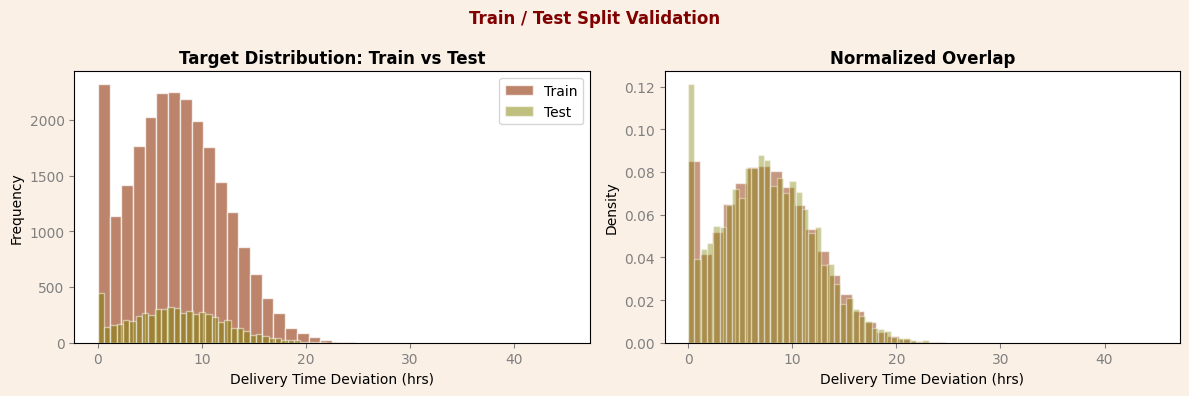

,Train,Test
count,24160.0000,6041.0000
mean,7.4970,7.5140
std,4.5450,4.5410
min,0.0000,0.0000
25%,4.1490,4.1320
50%,7.3370,7.3360
75%,10.6050,10.6360
max,45.0000,24.3320


In [ ]:
# 80/20 random split (on raw features, before encoding)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED
)

print("Split sizes (pre-encoding):")
print(f"  Train: {X_train_raw.shape[0]:,} rows ({X_train_raw.shape[0]/len(X_raw)*100:.0f}%)")
print(f"  Test:  {X_test_raw.shape[0]:,} rows ({X_test_raw.shape[0]/len(X_raw)*100:.0f}%)")

# --- OneHotEncoder: fit on train only, transform both ---
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error')
ohe.fit(X_train_raw[categorical_features])

# Get encoded column names
ohe_col_names = ohe.get_feature_names_out(categorical_features).tolist()

# Build final train/test DataFrames: numeric cols + encoded categorical cols
X_train = pd.concat([
    X_train_raw[numeric_features].reset_index(drop=True),
    pd.DataFrame(ohe.transform(X_train_raw[categorical_features]),
                 columns=ohe_col_names)
], axis=1)

X_test = pd.concat([
    X_test_raw[numeric_features].reset_index(drop=True),
    pd.DataFrame(ohe.transform(X_test_raw[categorical_features]),
                 columns=ohe_col_names)
], axis=1)

# Reset y indices to match X
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

all_feature_cols = numeric_features + ohe_col_names

print(f"\nPost-encoding feature set: {len(all_feature_cols)} columns")
for i, col in enumerate(all_feature_cols, 1):
    ftype = 'binary' if X_train[col].nunique() == 2 else 'continuous'
    print(f"  {i:2d}. {col} ({ftype})")

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# Verify target distribution is similar in both sets
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.set_facecolor('linen')

axes[0].hist(y_train, bins=40, color='sienna', edgecolor='white', alpha=0.7, label='Train')
axes[0].hist(y_test, bins=40, color='olive', edgecolor='white', alpha=0.5, label='Test')
axes[0].set_title('Target Distribution: Train vs Test', fontweight='bold')
axes[0].set_xlabel('Delivery Time Deviation (hrs)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].tick_params(axis='both', colors='gray')

# Density comparison
axes[1].hist(y_train, bins=40, density=True, color='sienna', edgecolor='white', alpha=0.6, label='Train (density)')
axes[1].hist(y_test, bins=40, density=True, color='olive', edgecolor='white', alpha=0.4, label='Test (density)')
axes[1].set_title('Normalized Overlap', fontweight='bold')
axes[1].set_xlabel('Delivery Time Deviation (hrs)')
axes[1].set_ylabel('Density')
axes[1].tick_params(axis='both', colors='gray')

fig.suptitle('Train / Test Split Validation', weight='bold', color='maroon')
plt.tight_layout()
plt.show()

# Summary stats comparison
split_stats = pd.DataFrame({
    'Train': y_train.describe(),
    'Test': y_test.describe()
}).round(3)

display(split_stats)

### 5.2 Scaling Strategy

Whether to scale depends on the model family:
- **Tree-based models** (Random Forest, Gradient Boosting, XGBoost): Scaling is **not needed** because splits are based on feature orderings, not distances or magnitudes.
- **Linear / regularized models** (Ridge, Lasso, ElasticNet, SVR): Scaling **is needed** because coefficient estimation and regularization penalties are sensitive to feature magnitude.

To prevent data leakage during cross-validation, **scaling is embedded inside a `Pipeline`** alongside each model that requires it. This ensures the `StandardScaler` is fit *only* on the CV training fold and applied to the held-out validation fold - the validation fold never influences the scaler's mean/std. Below we also prepare a standalone scaled version for quick inspection, but **all CV and test evaluation uses the Pipeline approach**.

In [ ]:
# --- Unscaled version (for tree-based models) ---
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

# --- Scaled version (for linear/regularized models) ---
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Verify scaling
print("Scaled training set - first 5 feature means (should be ~0):")
print(X_train_scaled.mean().head().round(6).to_string())
print("\nScaled training set - first 5 feature stds (should be ~1):")
print(X_train_scaled.std().head().round(6).to_string())

print(f"\n--- Data ready for modeling ---")
print(f"Unscaled: X_train_unscaled {X_train_unscaled.shape}, X_test_unscaled {X_test_unscaled.shape}")
print(f"Scaled:   X_train_scaled {X_train_scaled.shape}, X_test_scaled {X_test_scaled.shape}")
print(f"Target:   y_train {y_train.shape}, y_test {y_test.shape}")

Scaled training set - first 5 feature means (should be ~0):
traffic_congestion_level          -0.0000
warehouse_inventory_level          0.0000
loading_unloading_time             0.0000
handling_equipment_availability   -0.0000
weather_condition_severity        -0.0000

Scaled training set - first 5 feature stds (should be ~1):
traffic_congestion_level          1.0000
warehouse_inventory_level         1.0000
loading_unloading_time            1.0000
handling_equipment_availability   1.0000
weather_condition_severity        1.0000

--- Data ready for modeling ---
Unscaled: X_train_unscaled (24160, 20), X_test_unscaled (6041, 20)
Scaled:   X_train_scaled (24160, 20), X_test_scaled (6041, 20)
Target:   y_train (24160,), y_test (6041,)


---

# **Part 4: Model Development**

We evaluate nine regression models across three families:
- **Linear / regularized:** Linear Regression, Ridge, Lasso, ElasticNet, Polynomial Ridge (degree 2)
- **Tree-based:** Random Forest, Gradient Boosting, XGBoost
- **Kernel-based:** SVR (RBF)

All models are tuned via 5-fold cross-validation using RMSE as the primary metric (see section 6.1 for justification). Linear/regularized models use a `Pipeline` with `StandardScaler` to prevent data leakage during CV. Tree-based models use unscaled features.

In [ ]:
# Imports already loaded in cell 2 (consolidated)
# Models, CV, and metrics are all available from the top-level import block

In [ ]:
# Primary Metric
PRIMARY_METRIC = "rmse"

SCORING_MAP = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}
scoring = SCORING_MAP[PRIMARY_METRIC]

### 6.1 Why RMSE as the Primary Metric

We use Root Mean Squared Error (RMSE) as the primary evaluation metric for three reasons:

1. **Same-unit interpretability.** RMSE is expressed in hours (the same unit as `delivery_time_deviation`), making it immediately meaningful to logistics stakeholders. An RMSE of ~3.4 hours means the model's predictions are off by roughly 3.4 hours on average (weighted toward larger errors).
2. **Penalizes large errors.** In supply chain operations, a shipment that arrives 12 hours late is far more disruptive than three shipments that arrive 4 hours late each. RMSE's squared penalty naturally prioritizes reducing those large deviations, which aligns with operational risk management.
3. **Standard and simple.** RMSE is the most widely reported regression metric, making results easy to compare across models and communicate to non-technical audiences. We supplement with MAE (for a robust central tendency of error) and R^2 (for variance explained) but use RMSE as the optimization target.

In [ ]:
# Cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Tree-based models grid search
tree_candidates = {
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

tree_param_grids = {
    "RandomForest": {
        "n_estimators": [300, 600],
        "max_depth": [None, 12],
        "min_samples_leaf": [1, 5],
        "max_features": ["sqrt", "log2"]
    },
    "GradientBoosting": {
        "n_estimators": [300, 600],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3]
    },
}

In [ ]:
# Linear and regularized regression models - each wrapped in a Pipeline
# with StandardScaler so that scaling is re-fit on each CV training fold,
# preventing the validation fold from leaking into the scaler's statistics.
linear_candidates = {
    "LinearRegression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(random_state=42))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(random_state=42))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(random_state=42))]),
}

linear_param_grids = {
    "LinearRegression": {},

    "Ridge": {
        "model__alpha": [0.1, 1.0, 10.0]
    },

    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1]
    },

    "ElasticNet": {
        "model__alpha": [0.01, 0.1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8]

    },}

In [ ]:
# Grid search helper
def run_grid(estimator, param_grid, Xtr, ytr):
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    gs.fit(Xtr, ytr)
    return gs

In [ ]:
# Store results
results = []

In [ ]:
# Random forest
name = "RandomForest"

gs_randomf = run_grid(tree_candidates[name], tree_param_grids[name], X_train_unscaled, y_train)

best_model_randomf = gs_randomf.best_estimator_
preds_randomf = best_model_randomf.predict(X_test_unscaled)

rmse_randomf = np.sqrt(mean_squared_error(y_test, preds_randomf))
mae_randomf  = mean_absolute_error(y_test, preds_randomf)
r2_randomf   = r2_score(y_test, preds_randomf)

results.append({
    "family": "tree",
    "model": name,
    "best_cv_score": gs_randomf.best_score_,
    "best_params": gs_randomf.best_params_,
    "test_rmse": rmse_randomf,
    "test_mae": mae_randomf,
    "test_r2": r2_randomf
})

In [ ]:
# Gradient boosting
name = "GradientBoosting"

gs_gb = run_grid(tree_candidates[name], tree_param_grids[name], X_train_unscaled, y_train)

best_model_gb = gs_gb.best_estimator_
preds_gb = best_model_gb.predict(X_test_unscaled)

rmse_gb = np.sqrt(mean_squared_error(y_test, preds_gb))
mae_gb  = mean_absolute_error(y_test, preds_gb)
r2_gb   = r2_score(y_test, preds_gb)

results.append({
    "family": "tree",
    "model": name,
    "best_cv_score": gs_gb.best_score_,
    "best_params": gs_gb.best_params_,
    "test_rmse": rmse_gb,
    "test_mae": mae_gb,
    "test_r2": r2_gb
})

In [ ]:
# Ridge regression (Pipeline: StandardScaler -> Ridge)
name = "Ridge"

gs_ridge = run_grid(linear_candidates[name], linear_param_grids[name], X_train_unscaled, y_train)

best_model_ridge = gs_ridge.best_estimator_
preds_ridge = best_model_ridge.predict(X_test_unscaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, preds_ridge))
mae_ridge  = mean_absolute_error(y_test, preds_ridge)
r2_ridge   = r2_score(y_test, preds_ridge)

results.append({
    "family": "linear",
    "model": name,
    "best_cv_score": gs_ridge.best_score_,
    "best_params": gs_ridge.best_params_,
    "test_rmse": rmse_ridge,
    "test_mae": mae_ridge,
    "test_r2": r2_ridge
})

In [ ]:
# Lasso regression (Pipeline: StandardScaler -> Lasso)
name = "Lasso"

gs_lasso = run_grid(linear_candidates[name], linear_param_grids[name], X_train_unscaled, y_train)

best_model_lasso = gs_lasso.best_estimator_
preds_lasso = best_model_lasso.predict(X_test_unscaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, preds_lasso))
mae_lasso  = mean_absolute_error(y_test, preds_lasso)
r2_lasso   = r2_score(y_test, preds_lasso)

results.append({
    "family": "linear",
    "model": name,
    "best_cv_score": gs_lasso.best_score_,
    "best_params": gs_lasso.best_params_,
    "test_rmse": rmse_lasso,
    "test_mae": mae_lasso,
    "test_r2": r2_lasso
})

In [ ]:
# ElasticNet regression (Pipeline: StandardScaler -> ElasticNet)
name = "ElasticNet"

gs_elastic = run_grid(linear_candidates[name], linear_param_grids[name], X_train_unscaled, y_train)

best_model_elastic = gs_elastic.best_estimator_
preds_elastic = best_model_elastic.predict(X_test_unscaled)

rmse_elastic = np.sqrt(mean_squared_error(y_test, preds_elastic))
mae_elastic  = mean_absolute_error(y_test, preds_elastic)
r2_elastic   = r2_score(y_test, preds_elastic)

results.append({
    "family": "linear",
    "model": name,
    "best_cv_score": gs_elastic.best_score_,
    "best_params": gs_elastic.best_params_,
    "test_rmse": rmse_elastic,
    "test_mae": mae_elastic,
    "test_r2": r2_elastic
})

In [ ]:
# Linear regression (Pipeline: StandardScaler -> LinearRegression)
name = "LinearRegression"

gs_linear = run_grid(linear_candidates[name], linear_param_grids[name], X_train_unscaled, y_train)

best_model_linear = gs_linear.best_estimator_
preds_linear = best_model_linear.predict(X_test_unscaled)

rmse_linear = np.sqrt(mean_squared_error(y_test, preds_linear))
mae_linear  = mean_absolute_error(y_test, preds_linear)
r2_linear   = r2_score(y_test, preds_linear)

results.append({
    "family": "linear",
    "model": name,
    "best_cv_score": gs_linear.best_score_,
    "best_params": gs_linear.best_params_,
    "test_rmse": rmse_linear,
    "test_mae": mae_linear,

    "test_r2": r2_linear})

In [ ]:
# SVR (RBF kernel) - Pipeline with scaler to prevent CV leakage
svr_pipe = Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf"))])
svr_params = {"model__C": [1, 10], "model__epsilon": [0.1, 0.5], "model__gamma": ["scale", "auto"]}
gs_svr = run_grid(svr_pipe, svr_params, X_train_unscaled, y_train)
preds_svr = gs_svr.best_estimator_.predict(X_test_unscaled)

results.append({
    "family": "kernel", "model": "SVR_RBF",
    "best_cv_score": gs_svr.best_score_, "best_params": gs_svr.best_params_,
    "test_rmse": np.sqrt(mean_squared_error(y_test, preds_svr)),
    "test_mae": mean_absolute_error(y_test, preds_svr),
    "test_r2": r2_score(y_test, preds_svr),
})

In [ ]:
# Polynomial Ridge (degree 2) - Pipeline with scaler to prevent CV leakage
poly_pipe = Pipeline([("scaler", StandardScaler()),
                       ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                       ("ridge", Ridge(random_state=42))])
poly_params = {"ridge__alpha": [0.1, 1.0, 10.0, 100.0]}
gs_poly = run_grid(poly_pipe, poly_params, X_train_unscaled, y_train)
preds_poly = gs_poly.best_estimator_.predict(X_test_unscaled)
results.append({
    "family": "linear", "model": "PolyRidge_deg2",
    "best_cv_score": gs_poly.best_score_, "best_params": gs_poly.best_params_,
    "test_rmse": np.sqrt(mean_squared_error(y_test, preds_poly)),
    "test_mae": mean_absolute_error(y_test, preds_poly),
    "test_r2": r2_score(y_test, preds_poly),
})

In [ ]:
# XGBoost regressor - using unscaled data (tree-based models don't require scaling)
xgb_params = {
    "n_estimators": [300, 600], "learning_rate": [0.05, 0.1],
    "max_depth": [3, 6], "colsample_bytree": [0.7, 1.0],
}
gs_xgb = run_grid(xgb.XGBRegressor(random_state=42, verbosity=0), xgb_params, X_train_unscaled, y_train)
preds_xgb = gs_xgb.best_estimator_.predict(X_test_unscaled)
results.append({
    "family": "tree", "model": "XGBoost",
    "best_cv_score": gs_xgb.best_score_, "best_params": gs_xgb.best_params_,
    "test_rmse": np.sqrt(mean_squared_error(y_test, preds_xgb)),
    "test_mae": mean_absolute_error(y_test, preds_xgb),
    "test_r2": r2_score(y_test, preds_xgb),
})

In [ ]:
# Dataframe of results
results_df = pd.DataFrame(results)
results_df["cv_score_actual"] = -results_df["best_cv_score"]
results_df = results_df.sort_values("test_rmse").reset_index(drop=True)
display(results_df)

,family,model,best_cv_score,best_params,test_rmse,test_mae,test_r2,cv_score_actual
0,linear,LinearRegression,-3.4104,{},3.3696,2.7073,0.4493,3.4104
1,linear,Ridge,-3.4104,{'model__alpha': 10.0},3.3696,2.7073,0.4493,3.4104
2,linear,ElasticNet,-3.4103,"{'model__alpha': 0.01, 'model__l1_ratio': 0.8}",3.3701,2.7085,0.4491,3.4103
3,linear,Lasso,-3.4102,{'model__alpha': 0.01},3.3702,2.7085,0.4491,3.4102
4,tree,GradientBoosting,-3.4227,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",3.3758,2.7203,0.4473,3.4227
5,tree,XGBoost,-3.4264,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",3.3760,2.7185,0.4472,3.4264
6,linear,PolyRidge_deg2,-5.6823,{'ridge__alpha': 100.0},3.3766,2.7191,0.4470,5.6823
7,tree,RandomForest,-3.4467,"{'max_depth': 12, 'max_features': 'sqrt', 'min...",3.3972,2.7396,0.4403,3.4467
8,kernel,SVR_RBF,-3.4489,"{'model__C': 1, 'model__epsilon': 0.5, 'model_...",3.4006,2.7248,0.4391,3.4489


The model comparison results show that linear models performed slightly better than tree-based or kernel-based models on this dataset. Among all nine models tested, Linear Regression achieved the best overall performance with a test RMSE of ~3.37, and the regularized variants (Ridge, Lasso, ElasticNet) produced nearly identical results - indicating that the coefficient magnitudes are already well-behaved and strong regularization is not needed.

The tree-based models (Gradient Boosting, Random Forest, XGBoost) performed comparably but did not improve on the linear baselines. Despite the weak pairwise correlations observed in the EDA (section 2.4), the hypothesis that non-linear models would outperform was not supported - the additive linear structure seems sufficient for this feature set. XGBoost performed on par with Gradient Boosting, while Random Forest had the highest RMSE among the tree models.

The kernel-based SVR (RBF) and Polynomial Ridge (degree 2) models also did not meaningfully outperform the simple linear models. The polynomial expansion added considerable complexity without corresponding gains in RMSE.

Overall, the results suggest that the relationships between features and the target are largely linear, and Linear Regression was selected as the final model. It is the simplest model with competitive performance, and its coefficients are directly interpretable - an important property for supply chain stakeholders who need to understand which factors drive delivery deviations.

# Appendix

In [ ]:
# Feature importance comparison: Linear Regression, Ridge, Lasso, XGBoost, Random Forest
# Sorted by |Linear Regression coefficient| since LR is the selected model
linear_coefs = pd.Series(best_model_linear.named_steps['model'].coef_, index=X_train_unscaled.columns)
lasso_coefs = pd.Series(best_model_lasso.named_steps['model'].coef_, index=X_train_unscaled.columns)
ridge_coefs = pd.Series(best_model_ridge.named_steps['model'].coef_, index=X_train_unscaled.columns)
imp_xgb = pd.Series(gs_xgb.best_estimator_.feature_importances_, index=X_train_unscaled.columns)
imp_rf = pd.Series(best_model_randomf.feature_importances_, index=X_train_unscaled.columns)

comparison = pd.DataFrame({
    'LR Coef': linear_coefs,
    '|LR|': linear_coefs.abs(),
    'Ridge Coef': ridge_coefs,
    'Lasso Coef': lasso_coefs,
    'XGBoost Imp': imp_xgb,
    'RF Imp': imp_rf,
}).sort_values('|LR|', ascending=False)

comparison['LR Rank'] = range(1, len(comparison) + 1)
comparison['Ridge Rank'] = comparison['Ridge Coef'].abs().rank(ascending=False).astype(int)
comparison['Lasso Rank'] = comparison['Lasso Coef'].abs().rank(ascending=False).astype(int)
comparison['XGB Rank'] = comparison['XGBoost Imp'].rank(ascending=False).astype(int)
comparison['RF Rank'] = comparison['RF Imp'].rank(ascending=False).astype(int)
comparison['Lasso Selected'] = lasso_coefs.loc[comparison.index] != 0

display_cols = ['LR Coef', 'Ridge Coef', 'Lasso Coef', 'XGBoost Imp', 'RF Imp',
                'LR Rank', 'Ridge Rank', 'Lasso Rank', 'XGB Rank', 'RF Rank', 'Lasso Selected']

comparison[display_cols].style \
    .format({'LR Coef': '{:.4f}', 'Ridge Coef': '{:.4f}', 'Lasso Coef': '{:.4f}', 'XGBoost Imp': '{:.4f}', 'RF Imp': '{:.4f}'}) \
    .background_gradient(subset=['LR Coef'], cmap='RdBu_r', vmin=-linear_coefs.abs().max(), vmax=linear_coefs.abs().max()) \
    .background_gradient(subset=['Ridge Coef'], cmap='RdBu_r', vmin=-ridge_coefs.abs().max(), vmax=ridge_coefs.abs().max()) \
    .map(lambda v: 'color: red' if not v else '', subset=['Lasso Selected']) \
    .background_gradient(subset=['Lasso Coef'], cmap='RdBu_r', vmin=-lasso_coefs.abs().max(), vmax=lasso_coefs.abs().max()) \
    .background_gradient(subset=['RF Imp'], cmap='YlOrRd') \
    .background_gradient(subset=['XGBoost Imp'], cmap='YlOrRd')

,LR Coef,Ridge Coef,Lasso Coef,XGBoost Imp,RF Imp,LR Rank,Ridge Rank,Lasso Rank,XGB Rank,RF Rank,Lasso Selected
traffic_congestion_level,1.3718,1.3566,1.2129,0.1115,0.1601,1,1,1,2,2,True
driver_behavior_score,-1.1763,-1.1670,-1.1564,0.0922,0.0706,2,2,2,3,4,True
weather_condition_severity,1.1430,1.1243,0.9470,0.0814,0.1305,3,3,4,5,3,True
route_risk_level,0.7780,0.8016,1.0187,0.4158,0.2877,4,4,3,1,1,True
handling_equipment_availability,-0.6470,-0.6468,-0.6375,0.0870,0.0260,5,5,5,4,11,True
port_congestion_level,0.4454,0.4452,0.4352,0.0203,0.0355,6,6,6,9,9,True
supplier_reliability_score,-0.3431,-0.3430,-0.3377,0.0345,0.0388,7,7,7,7,8,True
lead_time_days,0.3354,0.3354,0.3298,0.0259,0.0395,8,8,8,8,7,True
loading_unloading_time,0.2781,0.2780,0.2669,0.0127,0.0276,9,9,9,10,10,True
day_of_week_Tuesday,-0.0538,-0.0538,-0.0215,0.0033,0.0016,10,10,10,19,16,True


The table above compares feature importance across four model families, sorted by the absolute value of the Linear Regression coefficients (the selected model). The ranking is broadly consistent across methods - `traffic_congestion_level`, `driver_behavior_score`, `weather_condition_severity`, `route_risk_level`, and `handling_equipment_availability` emerge as top predictors in both coefficient-based and tree-based importance measures. The Lasso "Selected" column shows which features survive L1 regularization; features zeroed out by Lasso are likely noise contributors. The agreement between Linear Regression and Ridge coefficients is expected given their near-identical performance, while the XGBoost and Random Forest importance rankings offer a complementary view of which features contribute most through non-linear splits.

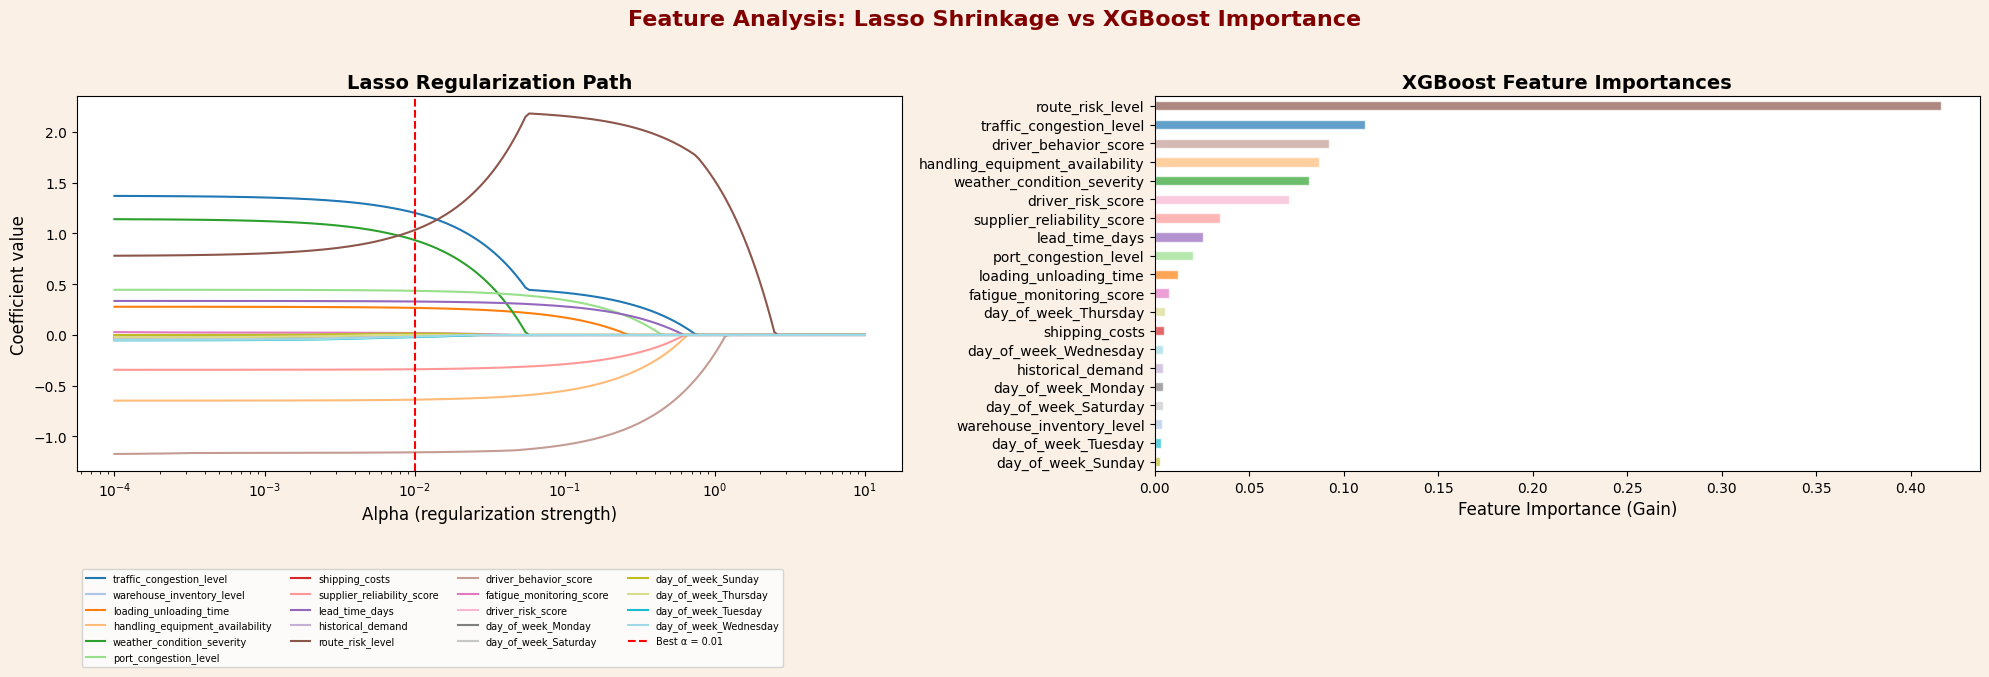

In [ ]:
# Lasso regularization path + XGBoost feature importances (side by side)

# --- Lasso path data ---
X_scaled = best_model_lasso.named_steps['scaler'].transform(X_train_unscaled)
alphas_grid = np.logspace(-4, 1, 200)
alphas_path, coefs_path, _ = lasso_path(X_scaled, y_train, alphas=alphas_grid)

# --- XGBoost importance data ---
imp = pd.Series(gs_xgb.best_estimator_.feature_importances_, index=X_train_unscaled.columns)
imp_sorted = imp.sort_values(ascending=True)

# Shared tab20 color map
cmap = plt.cm.tab20
feature_color_map = {feat: cmap(i / X_train_unscaled.shape[1]) for i, feat in enumerate(X_train_unscaled.columns)}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.set_facecolor('linen')

# Left: Lasso regularization path
for i, feat in enumerate(X_train_unscaled.columns):
    axes[0].plot(alphas_path, coefs_path[i], linewidth=1.5, label=feat, color=feature_color_map[feat])
axes[0].axvline(best_model_lasso.named_steps['model'].alpha, color='red',
                linestyle='--', linewidth=1.5,
                label=f"Best α = {best_model_lasso.named_steps['model'].alpha}")
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (regularization strength)', fontsize=12)
axes[0].set_ylabel('Coefficient value', fontsize=12)
axes[0].set_title('Lasso Regularization Path', weight='bold', fontsize=14)
axes[0].legend(bbox_to_anchor=(0, -0.25), loc='upper left', fontsize=7, ncol=4)

# Right: XGBoost feature importances
bar_colors = [feature_color_map[feat] for feat in imp_sorted.index]
imp_sorted.plot(kind='barh', color=bar_colors, edgecolor='white', alpha=0.7, ax=axes[1])
axes[1].set_xlabel('Feature Importance (Gain)', fontsize=12)
axes[1].set_title('XGBoost Feature Importances', weight='bold', fontsize=14)

fig.suptitle('Feature Analysis: Lasso Shrinkage vs XGBoost Importance',
             weight='bold', color='maroon', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The Lasso regularization path (left) shows how feature coefficients shrink toward zero as alpha increases. Features that persist at higher alpha values (e.g. `route_risk_level`, `driver_behavior_score`) have the strongest predictive signal, while features that collapse early are less influential. The red dashed line marks the best alpha selected by cross-validation. The XGBoost importance plot (right) provides a complementary, non-linear perspective - features that contribute the most gain during tree splits are ranked highest. Together, these two views confirm that a small subset of features drives most of the predictive power.

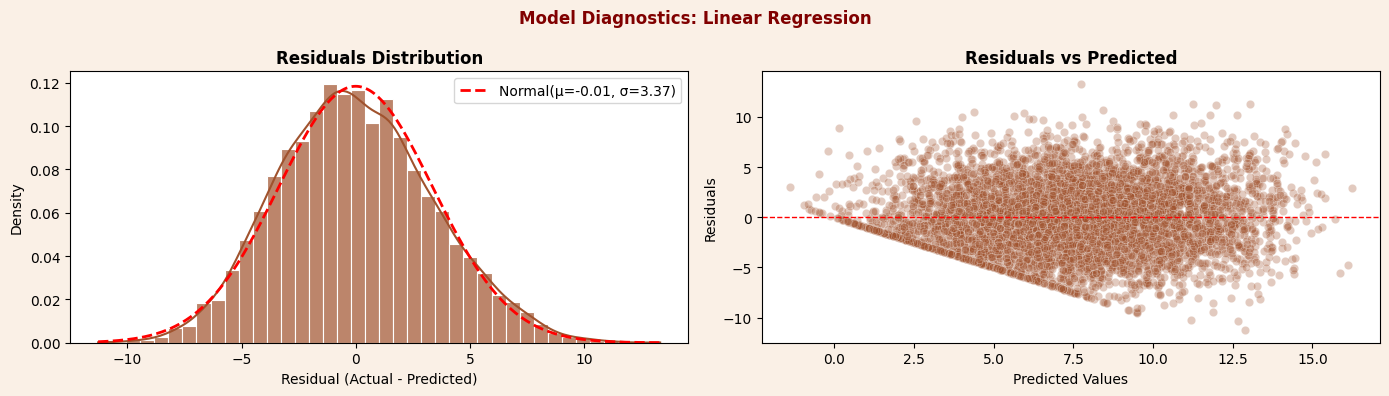

In [ ]:
# residual distribution compared to normal distribution
residuals = y_test - preds_linear
mu, std = residuals.mean(), residuals.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.set_facecolor('linen')

# Histogram with KDE
sns.histplot(residuals, bins=40, kde=True, color='sienna', edgecolor='white', alpha=0.7,
             stat='density', ax=axes[0])

# Overlay normal distribution curve
x_vals = np.linspace(residuals.min(), residuals.max(), 300)
axes[0].plot(x_vals, norm.pdf(x_vals, mu, std), color='red', lw=2, linestyle='--', label=f'Normal(μ={mu:.2f}, σ={std:.2f})')
axes[0].legend()
axes[0].set_title('Residuals Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Density')

# Residuals vs Predicted
sns.scatterplot(x=preds_linear, y=residuals, alpha=0.3, color='sienna', edgecolor='white', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', lw=1)
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')

fig.suptitle('Model Diagnostics: Linear Regression', weight='bold', color='maroon')
plt.tight_layout()
plt.show()

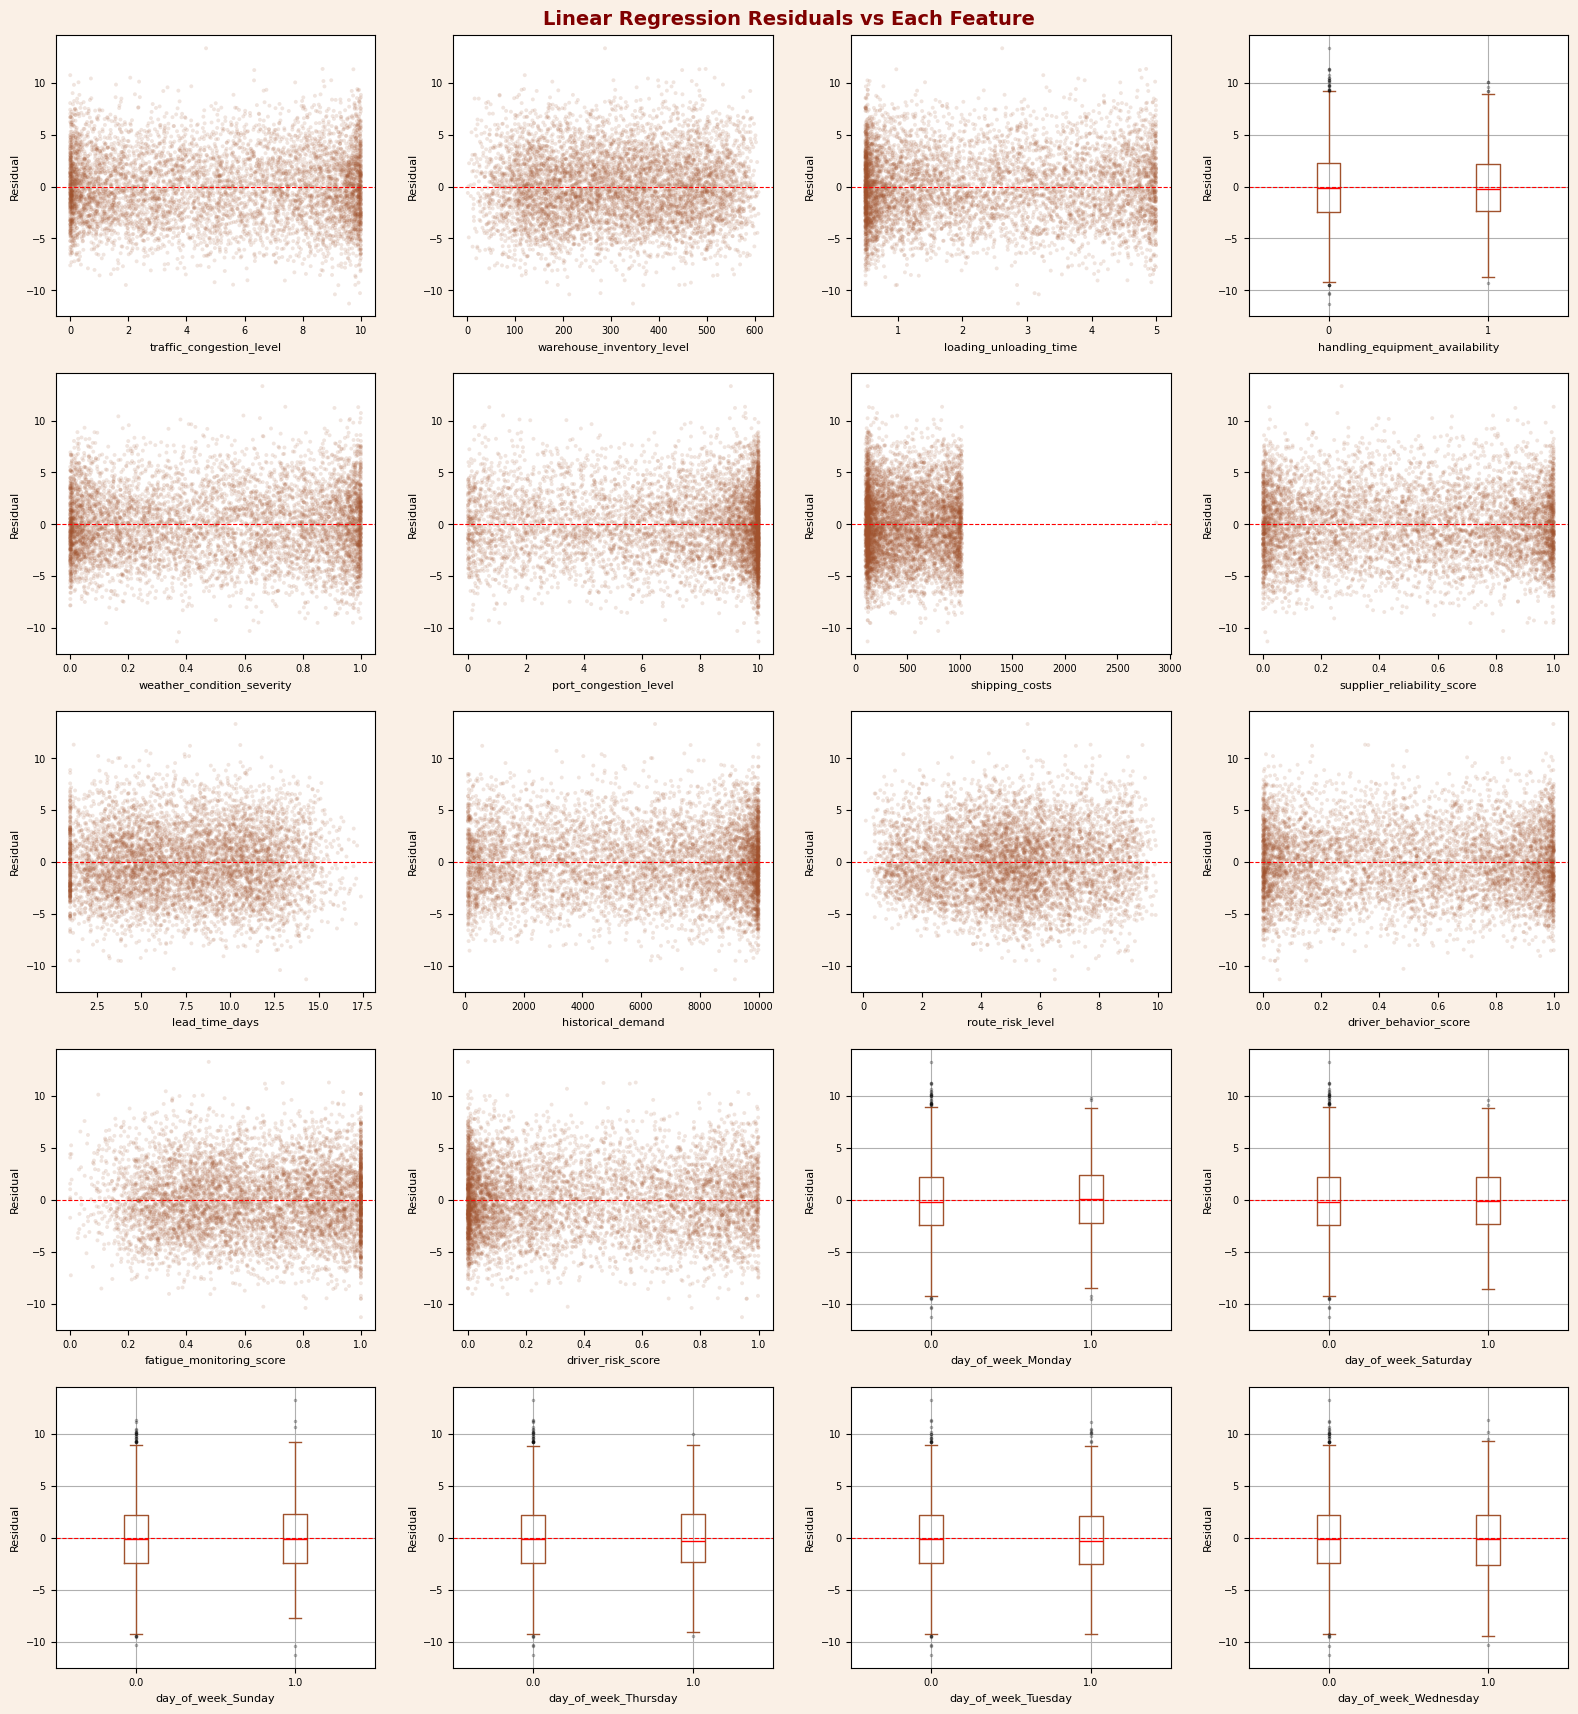

In [ ]:
# Residuals vs each feature (Linear Regression)
residuals = y_test - preds_linear
features = X_test_unscaled.columns.tolist()
n = len(features)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(4 * n_cols_plot, 3.5 * n_rows_plot))
fig.set_facecolor('linen')
axes = axes.flatten()

for i, feat in enumerate(features):
    vals = X_test_unscaled[feat]
    if vals.nunique() <= 6:
        # Binary / low-cardinality categorical → box plot
        resid_df = pd.DataFrame({'feature': vals.values, 'residual': residuals.values})
        resid_df.boxplot(column='residual', by='feature', ax=axes[i],
                         boxprops=dict(color='sienna'), medianprops=dict(color='red'),
                         whiskerprops=dict(color='sienna'), capprops=dict(color='sienna'),
                         flierprops=dict(marker='.', markersize=3, alpha=0.3, color='sienna'))
        axes[i].set_title('')
        axes[i].set_xlabel(feat, fontsize=8)
    else:
        # Continuous → scatter plot
        axes[i].scatter(vals, residuals, alpha=0.15, s=8, color='sienna', edgecolor='none')
        axes[i].set_xlabel(feat, fontsize=8)
    axes[i].axhline(0, color='red', linestyle='--', lw=0.8)
    axes[i].set_ylabel('Residual', fontsize=8)
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Linear Regression Residuals vs Each Feature', weight='bold', color='maroon', fontsize=14)
plt.tight_layout(pad=1.5)
plt.show()

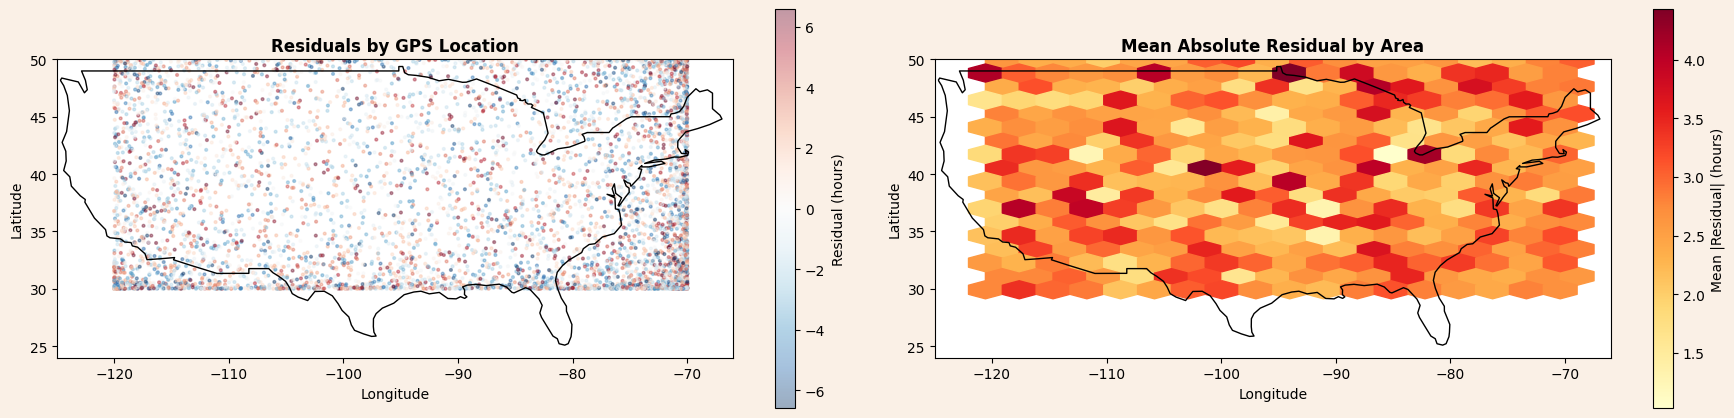

In [ ]:
# Residuals by location - scatter map colored by residual (Linear Regression)

# Load US border (Natural Earth 110m)
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
us = world[world['NAME'] == 'United States of America']

test_idx = X_test_raw.index
lat = df.loc[test_idx, 'vehicle_gps_latitude'].values
lon = df.loc[test_idx, 'vehicle_gps_longitude'].values
residuals = (y_test - preds_linear).values

# Clip view to contiguous US bounds (points outside will be off-canvas)
LON_MIN, LON_MAX = -125, -66
LAT_MIN, LAT_MAX = 24, 50

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.set_facecolor('linen')

for ax in axes:
    us.boundary.plot(ax=ax, color='black', linewidth=1)
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

# Left: scatter colored by residual
sc = axes[0].scatter(lon, lat, c=residuals, cmap='RdBu_r', s=4, alpha=0.4,
                     vmin=-np.percentile(np.abs(residuals), 95),
                     vmax=np.percentile(np.abs(residuals), 95))
fig.colorbar(sc, ax=axes[0], shrink=0.7, label='Residual (hours)')
axes[0].set_title('Residuals by GPS Location', fontweight='bold')

# Right: hexbin of mean absolute residual
hb = axes[1].hexbin(lon, lat, C=np.abs(residuals), reduce_C_function=np.mean,
                     gridsize=20, cmap='YlOrRd', mincnt=3,
                     extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
fig.colorbar(hb, ax=axes[1], shrink=0.7, label='Mean |Residual| (hours)')
axes[1].set_title('Mean Absolute Residual by Area', fontweight='bold')

plt.tight_layout()
plt.show()

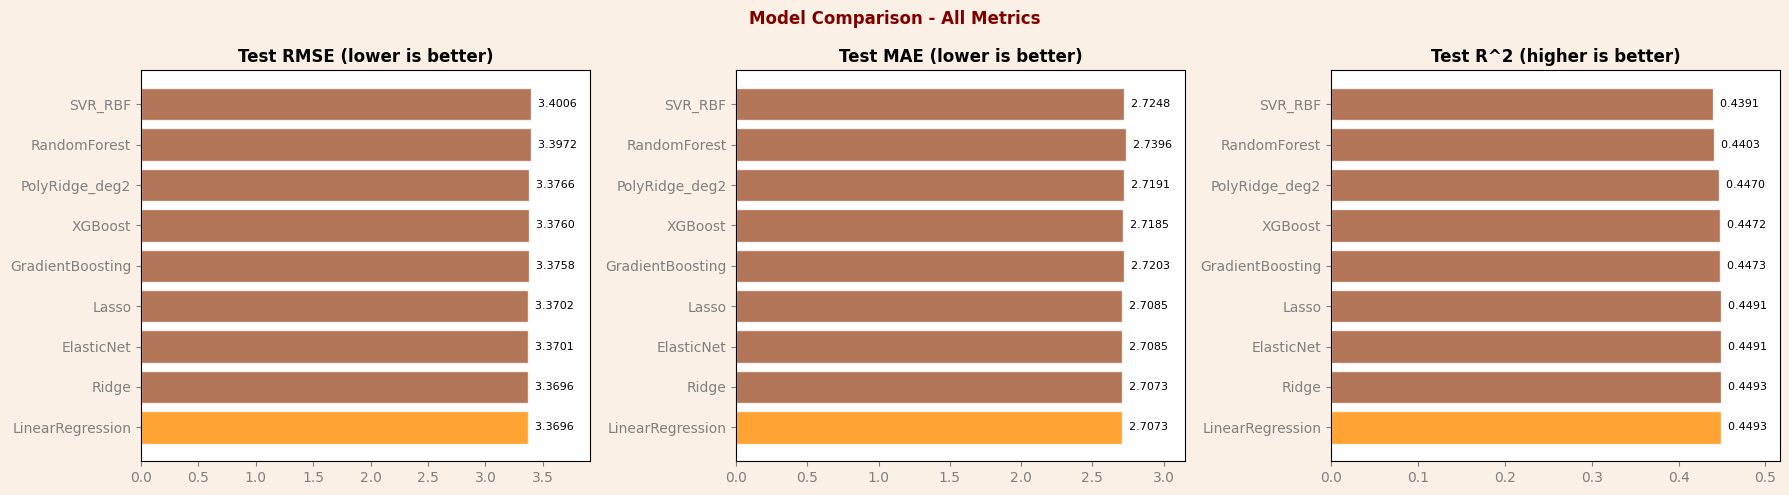

In [ ]:
# Model comparison bar chart (RMSE, MAE, R^2 side by side)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('linen')

models = results_df['model']
colors = ['darkorange' if m == 'LinearRegression' else 'sienna' for m in models]

for ax, metric, title in zip(axes,
                              ['test_rmse', 'test_mae', 'test_r2'],
                              ['Test RMSE (lower is better)', 'Test MAE (lower is better)', 'Test R^2 (higher is better)']):
    vals = results_df[metric]
    bars = ax.barh(models, vals, color=colors, edgecolor='white', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='both', colors='gray')
    for bar, v in zip(bars, vals):
        ax.text(v, bar.get_y() + bar.get_height() / 2, f'  {v:.4f}', va='center', fontsize=8)
    ax.set_xlim(0, max(vals) * 1.15)

fig.suptitle('Model Comparison - All Metrics', weight='bold', color='maroon')
plt.tight_layout()
plt.show()

---